Objectif: Analyse des facteurs inluençant les achats en ligne
###### Il sied de noter que notre variable cible est NbAchat_Web

In [1]:
#Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [2]:
df_original=pd.read_csv("C:/Users/Kardo BALOSSA/Data_Analyis_Projects/marketing-data-analyst-project/Data/Clean/dataset_cleaned.csv")
df=df_original.copy()

In [3]:
#Vérification de la réussite du chargment
df.head(10)

,ID,Annee_naissance,Niveau_Education,Statut_Marital,Revenu,Nb_Enfants,Nb_Ado,Nbjour_Dernier_Achat,Montant_Vins,Montant_Fruits,...,Plaintes,Pays,Montant_Total,Date_Enrollement,Age,Groupe_Age,Total_Enfants,Groupe_TotalEnfants,Revenu_Manquant,NbAchat_Total
0,1826,1970,Graduate,Divorced,84835.0,0,0,0,189,104,...,False,Spain,1190,2014-06-16,44,35-45,0,0,False,15
1,1,1961,Graduate,Single,57091.0,0,0,0,464,5,...,False,Canada,577,2014-06-15,53,45-60,0,0,False,18
2,10476,1958,Graduate,Married,67267.0,0,1,0,134,11,...,False,USA,251,2014-05-13,56,45-60,1,0,False,11
3,1386,1967,Graduate,Married,32474.0,1,1,0,10,0,...,False,Australia,11,2014-05-11,47,45-60,2,1,False,4
4,5371,1989,Graduate,Single,21474.0,1,0,0,6,16,...,False,Spain,91,2014-04-08,25,18-25,1,0,False,8
5,7348,1958,PhD,Single,71691.0,0,0,0,336,130,...,False,Spain,1192,2014-03-17,56,45-60,0,0,False,17
6,4073,1954,2n Cycle,Married,63564.0,0,0,0,769,80,...,False,Germany,1215,2014-01-29,60,45-60,0,0,False,28
7,1991,1967,Graduate,Married,44931.0,0,1,0,78,0,...,False,Spain,96,2014-01-18,47,45-60,1,0,False,7
8,4047,1954,PhD,Married,65324.0,0,1,0,384,0,...,False,USA,544,2014-01-11,60,45-60,1,0,False,20
9,9477,1954,PhD,Married,65324.0,0,1,0,384,0,...,False,India,544,2014-01-11,60,45-60,1,0,False,20


In [4]:
#Liste des colonnes
df.columns

Index(['ID', 'Annee_naissance', 'Niveau_Education', 'Statut_Marital', 'Revenu',
       'Nb_Enfants', 'Nb_Ado', 'Nbjour_Dernier_Achat', 'Montant_Vins',
       'Montant_Fruits', 'Montant_Viandes', 'Montant_Poissons',
       'Montant_Sucreries', 'Montant_Or', 'NbAchat_Remise', 'NbAchat_SiteWeb',
       'NbAchat_Catalogue', 'NbAchat_Magasin', 'NbVisit_SiteWebCeMois',
       'Campagne3', 'Campagne4', 'Campagne5', 'Campagne1', 'Campagne2',
       'Reponse', 'Plaintes', 'Pays', 'Montant_Total', 'Date_Enrollement',
       'Age', 'Groupe_Age', 'Total_Enfants', 'Groupe_TotalEnfants',
       'Revenu_Manquant', 'NbAchat_Total'],
      dtype='str')

In [5]:
#Présentattion de la structure du dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2232 entries, 0 to 2231
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2232 non-null   int64  
 1   Annee_naissance        2232 non-null   int64  
 2   Niveau_Education       2232 non-null   str    
 3   Statut_Marital         2232 non-null   str    
 4   Revenu                 2232 non-null   float64
 5   Nb_Enfants             2232 non-null   int64  
 6   Nb_Ado                 2232 non-null   int64  
 7   Nbjour_Dernier_Achat   2232 non-null   int64  
 8   Montant_Vins           2232 non-null   int64  
 9   Montant_Fruits         2232 non-null   int64  
 10  Montant_Viandes        2232 non-null   int64  
 11  Montant_Poissons       2232 non-null   int64  
 12  Montant_Sucreries      2232 non-null   int64  
 13  Montant_Or             2232 non-null   int64  
 14  NbAchat_Remise         2232 non-null   int64  
 15  NbAchat_SiteWeb

Note : 
###### Identificaton des variables explicatives. Toutes les variables en dehors des montants sont suspectées d'influencer les achats en ligne



Analyse univariée: Analyses statistiques et graphiques

In [6]:
#Variables explicatives suspectes catégorielles
var_category=["Groupe_Age","Niveau_Education","Groupe_TotalEnfants","Statut_Marital","Pays"]

#Variables explicatives suspectes booléennes
var_bool=["Campagne1","Campagne2","Campagne3","Campagne4","Campagne5","Plaintes"]

Analyses statistiques et graphiques des variables numériques

In [7]:
#Description des variables numériques
df["Revenu"].describe()

count      2232.000000
mean      51944.322357
std       21428.387421
min        1730.000000
25%       35434.750000
50%       51445.500000
75%       68275.750000
max      162397.000000
Name: Revenu, dtype: float64

Interprétation :
###### Revenu : Après traitement la variable Revenu ne présente plus d'anomalies majeures.  L'analyse statistique montre que la moyenne(51902)   est légèrement supérieure à la médiane(51342) indiquant une distribution asymétrique positive. Cela suggère la présence des clients à revenus élevés qui tirent la distribution vers la droite. Par ailleurs, l'écart type (21470) traduit une forte dispersion des revenus autour de la moyenne. Les clients ont des revenus très variés, ce qui suggère d'adapter les campagnes marketing aux différents niveaux de revenu des clients. Aussi la majorité (75%) des clients ont des revenus inferieurs ou égaux à 68275,75 ce qui peut influencer le comportement d'achat et les réponses aux campagnes.

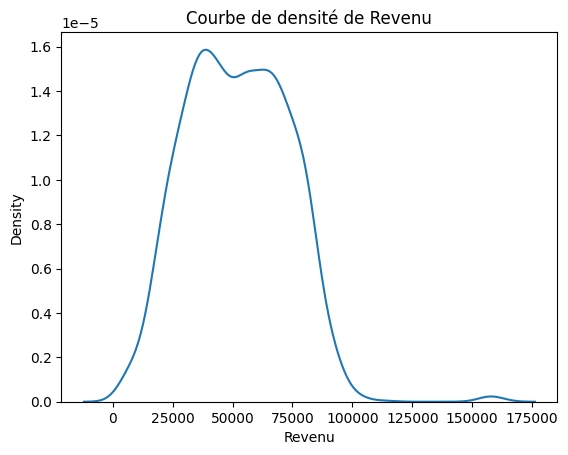

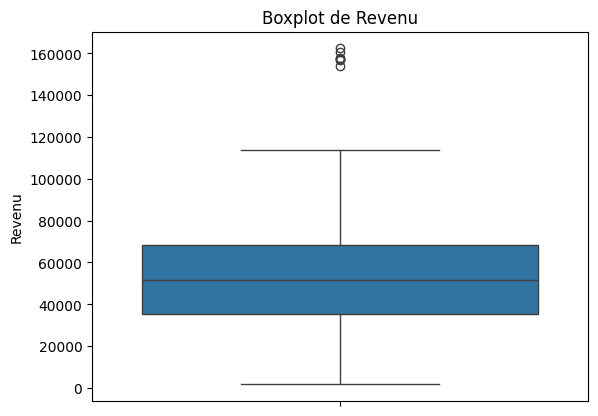

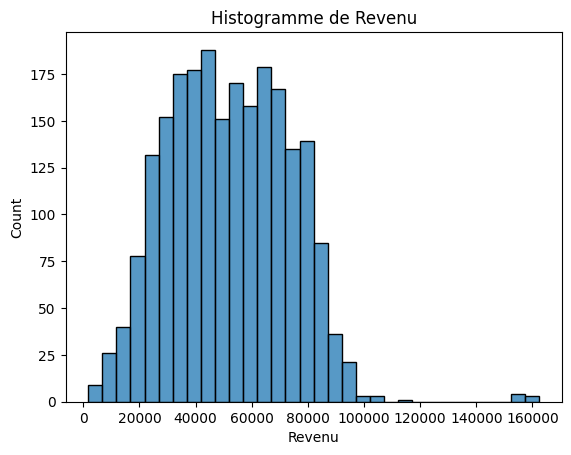

In [8]:
#Analyse graphique des variables numériques

#KDEplot
sns.kdeplot(df["Revenu"])
plt.title(f"Courbe de densité de Revenu")
plt.show()

#Boxplot
sns.boxplot(df["Revenu"])
plt.title(f"Boxplot de Revenu")
plt.show()

#Histogramme
sns.histplot(df["Revenu"])
plt.title(f"Histogramme de Revenu")
plt.show()


Interprétation :
###### La majorité des clients ont un revenu entre 20000 et 80000
###### Une minorité de clients a un revenu assez élevé mais pas extrême par rapport aux autres

Analyses statistique et graphique des variables catégorielles 

In [9]:
#Description des variables catégorielles
for i in var_category:
    print(i)
    print(df[i].describe())

Groupe_Age
count      2230
unique        5
top       35-45
freq        755
Name: Groupe_Age, dtype: object
Niveau_Education
count         2232
unique           5
top       Graduate
freq          1125
Name: Niveau_Education, dtype: object
Groupe_TotalEnfants
count     2232
unique       3
top          0
freq      1758
Name: Groupe_TotalEnfants, dtype: object
Statut_Marital
count        2232
unique          4
top       Married
freq         1442
Name: Statut_Marital, dtype: object
Pays
count      2232
unique        8
top       Spain
freq       1094
Name: Pays, dtype: object


Interprétation :
###### Group_Age : Après analyse univariée statistique, nous remarquons que la majorité (755) des clients est dans la tranche d'âge de 35 à 45
###### Niveau_Education :  L'analyse univariée statistique indique une fréquence élevée (1125) de clients dont le niveau d'éducation est Graduate
###### Groupe_TotalEnfants : L'analyse univariée statistique indique une fréquence élevée (1123) de clients qui n'ont pas d'enfants
###### Statut_Marital : L'analyse univariée statistique indique une fréquence élevée (1125) de clients dont le statut matrimonial est Married
###### Pays :  L'analyse univariée statistique indique une fréquence élevée (1094) des clients vivant en Espagen

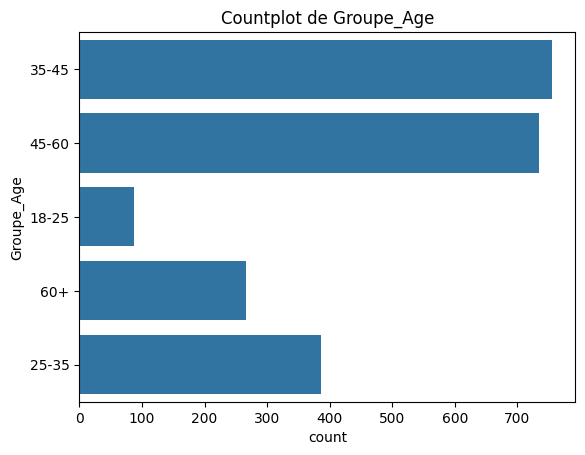

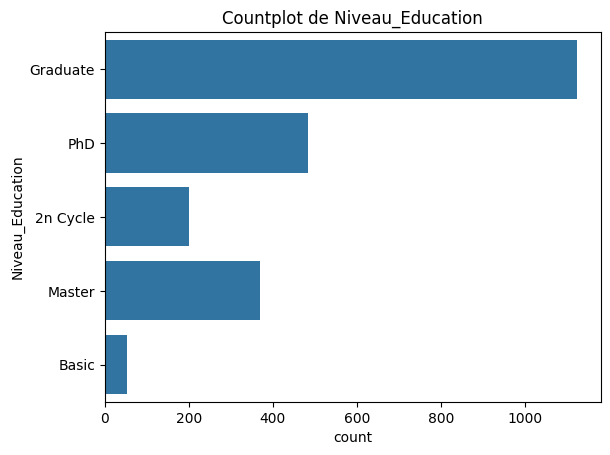

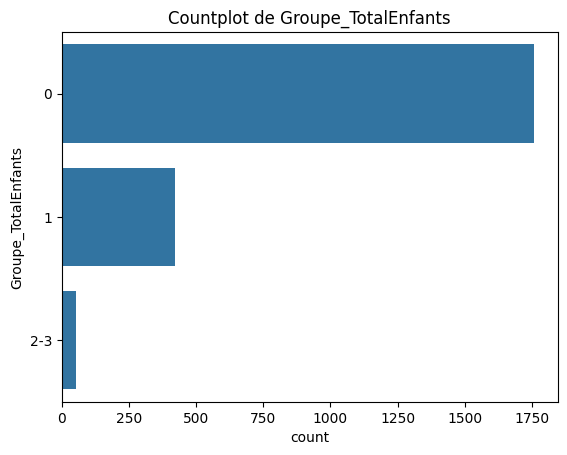

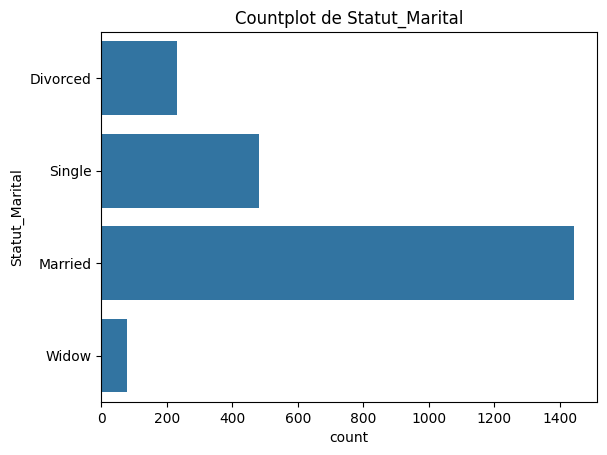

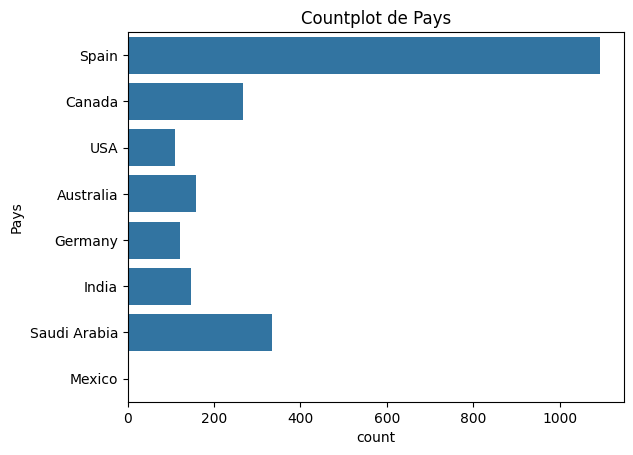

In [10]:
#Analyse graphique des variables catégorielles

#Countplot
for col in var_category:
    sns.countplot(df[col])
    plt.title(f"Countplot de {col}")
    plt.show()

Interprétation :
###### Group_Age : La tranche d'âge des clients allant de 18 à 25ans est la moins fréquente au sein de la compagnie et celle allant de 35 à 45 est la plus fréquente et devance légèrement la tranche d'âge de 45 à 60 ans

###### Niveau_Education : Plus de 1100 clients sont licenciés. Très peu de clients ont un niveau d'éducation basique pendant qu'environ 400, 300 et 200 ont respectivement un niveau doctorat, master et second cycle

###### Groupe_TotalEnfants : La majorité des clients de la compagnie n'ont pas une grande charge familiale (plus de 1100 cllients ont 0 enfants) environ 400 ont 1 enfant et très peu en ont 2 et plus. 

###### Statut_Marital : Nous observons que la majorité des clients sont marriés, environ 400 qui sont célibataires, environ 200 qui sont divorcés et environ moins de 100 qui sont veufs.

###### Pays : La majorité des clients vit en Espagnes et très peu vivent au Mexique (environ 5). Nous observons une densité assez importante des clients en Arabie Saoudite et au Canada. Dans chaque autre pays, nous observons environ moins de 200 clients 

Analyses statistique et graphique des variables booléennes

In [11]:
#Description des variables booléennes
for i in var_bool:
    print(i)
    print(df[i].describe())

Campagne1
count      2232
unique        2
top       False
freq       2089
Name: Campagne1, dtype: object
Campagne2
count      2232
unique        2
top       False
freq       2202
Name: Campagne2, dtype: object
Campagne3
count      2232
unique        2
top       False
freq       2069
Name: Campagne3, dtype: object
Campagne4
count      2232
unique        2
top       False
freq       2065
Name: Campagne4, dtype: object
Campagne5
count      2232
unique        2
top       False
freq       2071
Name: Campagne5, dtype: object
Plaintes
count      2232
unique        2
top       False
freq       2212
Name: Plaintes, dtype: object


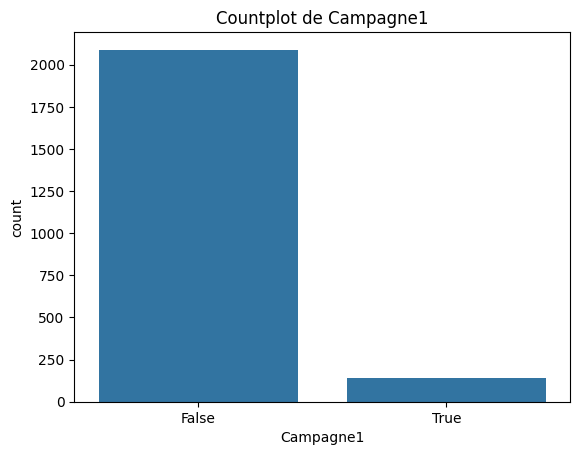

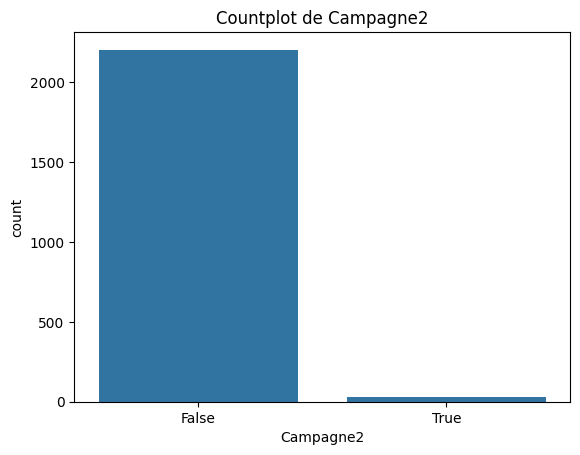

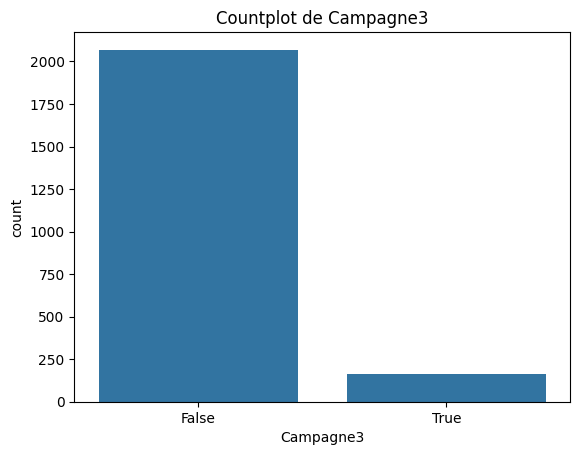

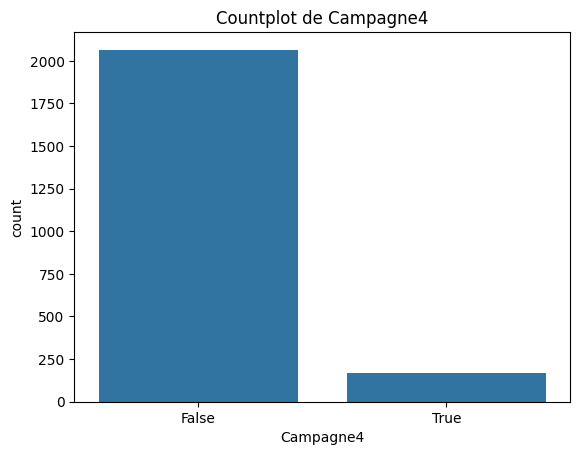

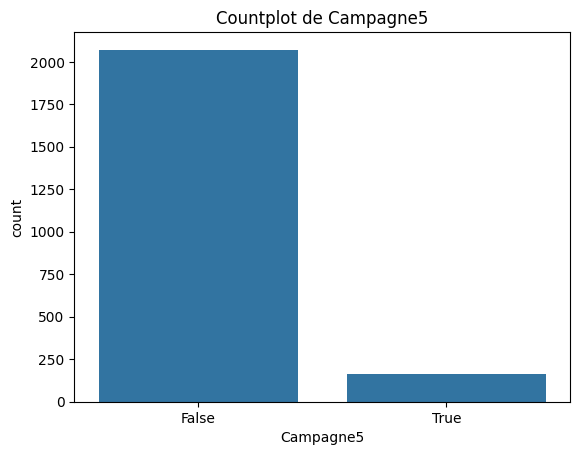

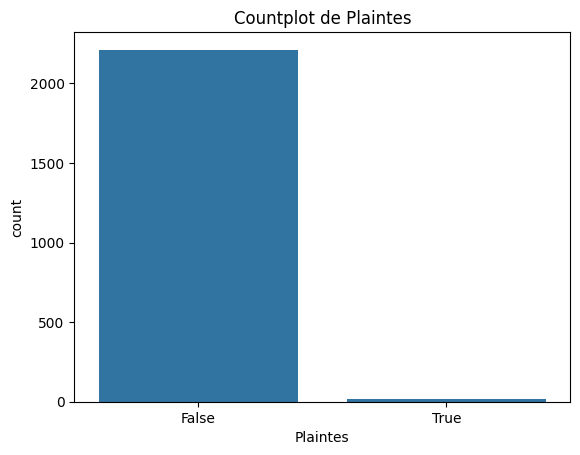

In [12]:
#Analyse graphique des variables booléennes()
for col in var_bool:
    sns.countplot(x=df[col])
    plt.title(f"Countplot de {col}")
    plt.show()
    

Interprétation :
###### L'entreprise, via ses cinq campagnes marketing a enregistré plus 2000 refus d'adhération à chaque campagne
###### Malgré ces refus, l'entreprise a enregistré exactement 2212 clients qui ne se sont pas plaints au cours de ces deux dernières années(2012-2014). Cela indique que malgré leur refus aux différentes offres, les clients sont satisfaits

Analyse bivariée

Variables numériques

Revenu vs NbAchat_SiteWeb

###### Nous allons évaluer la relation entre ces deux variables numériques via le méthode de correlation de Pearson ou celle de Spearman. Pour faire le choix entre ces deux méthodes, il sied de déterminer la nature de la distribution des données

In [13]:
#Vérifions la nature de la distribution de la série de données(Revenu)
#Vérification de la normalisattion des données

def test_shap(df,i):
    if i in df.select_dtypes(exclude="number"):
        print(f"Le test de shapiro n'est valide que pour les données numériques")
        return
    if i in df.select_dtypes(include='number').columns:
        stat_test, p=stats.shapiro(df[i])
        print(i)
        if p>0.05 :
            print("Les données suivent la loi normale")
        else:
            print("Les données ne suivent par la loi normale")  

In [14]:
var=["NbAchat_SiteWeb","Revenu"]
for i in var:
    test_shap(df,i)

NbAchat_SiteWeb
Les données ne suivent par la loi normale
Revenu
Les données ne suivent par la loi normale


Interprétation :
###### Nous remarquons que les deux variables ne suivent pas la loi normale. Nous allons donc procéder par la méthode de correlation de Spearman pour évaluer la relation entre ces deux variables numériques

In [15]:
#Analyse statistique
coeff_spearman=stats.spearmanr(df["NbAchat_SiteWeb"],df["Revenu"])
print(f"Coéfficient de correlation de spearman:{coeff_spearman.statistic}\n")
print(f"P-value:{coeff_spearman.pvalue}\n")
if coeff_spearman.pvalue>0.05 :
    print("Il n'existe pas une relation entre les deux variables")
else:
    print("Il existe une relation entre les deux variables")  


Coéfficient de correlation de spearman:0.5732023691086412

P-value:3.814029776797081e-195

Il existe une relation entre les deux variables


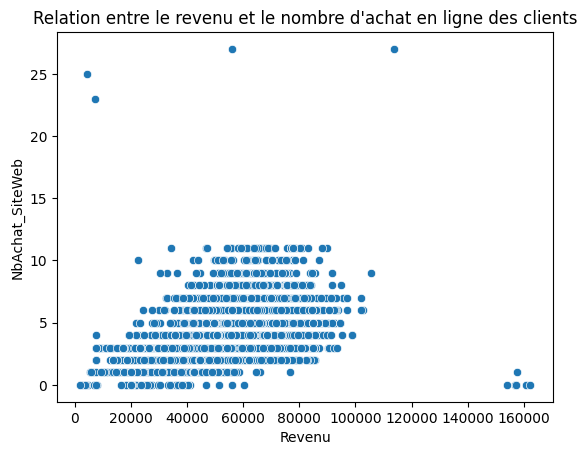

In [16]:
#Analyse graphique
sns.scatterplot(x=df["Revenu"],y=df["NbAchat_SiteWeb"])
plt.title(f"Relation entre le revenu et le nombre d'achat en ligne des clients")
plt.show()


Interprétation : 
###### L'analyse bivariée statistique indique une correlation de 0,57 entre  les deux variables ce qui indique une relation positive moédérée entre celles-ci. Cela suggère que les clients à revenu élevé ont tendance à acheter davantage en ligne.
###### L'analyse bivarié graphique indique que certains clients à revenu élevé et faible ont un grand nombre d'achat en ligne (aux environs de 22). Aussi, nous observons que, plus le revenu est élevé et plus le nombre d'achat en ligne augmente bien qu'il y ait certains client à revenu élevé qui achètent moins en ligne et d'autres à revenu faible qui achètent plus ligne. Cela suggère que le revenu des clients n'est pas le seul facteur qui influence les achats en ligne. D'autres facteurs doivent être pris en compte pour expliquer le comportement d'achat en ligne des clients


Variables catégorielles

Groupe_Age vs NbAchat_SiteWeb

###### Il y a plus de deux groupes dans Groupe_Age. Le choix du test pour vérifier l'existence de la relation est entre le test de l'ANOVA et le test Kruskal-Wallis
###### Vérifions la normalité des données dans chaque tranche d'âge et l'homogéité des variances

In [17]:
#Vérification de l'homogénéité des variances
def test_levene(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle")
        return

    groupe_lev=[df[df[var_cat]==groupe][num] for groupe in df[var_cat].unique() if len(df[df[var_cat] == groupe]) > 1]#regoupe le nombre d'achat en ligne en fonction des tranches d'âge
            
    if len(groupe_lev)> 1:

        stat, p=stats.levene(*groupe_lev)
        print(f"Levene test : stat={stat}, p={p}")

        if p > 0.05:
            print("\n Les variances sont homogènes")
        else:
            print("\n Les variances sont non homogènes")
    else:
        print(f"Le test nécessite plus de 2 groupes pour être réalisé")

In [18]:
test_levene(df,"NbAchat_SiteWeb","Groupe_Age")

Levene test : stat=2.7156815409018416, p=0.028408334738472884

 Les variances sont non homogènes


Interprétation :
###### Les variaances ne sont pas homogènes. Le test d'ANOVA n'est pas applicable. Effectuons donc le test de Kruskal-Wallis

In [19]:
#Fonction pour le test de Kruskal-Wallis
def test_kruskal(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle")
        return

    groupe_kw=[df[df[var_cat]==groupe][num] for groupe in df[var_cat].unique() if len(df[df[var_cat] == groupe]) > 1]#regoupe le nombre d'achat en ligne en fonction des tranches d'âge
    k=len(groupe_kw)

    if k> 2:
        stat, p=stats.kruskal(*groupe_kw)
        print(f"Kruskal test : stat={stat}, p={p}")
        if p > 0.05:
            print("Décision : Pas de différence significative entre les médianes des différents groupes")

        else:
            print("Décision : Différence significative entre les médianes des différents groupes")
        n=sum(len(g) for g in groupe_kw)
        epsilon2=(stat-k+1)/(n-k)
        print(f"Taille de l'effet : {epsilon2}")
        if epsilon2<0.01:
            print(f"Force de la relation : négligeable")
        elif epsilon2<0.06:
            print(f"Force de la relation : faible")
        elif epsilon2<0.14:
            print(f"Force de la relation : modérée")
        else:
            print(f"Force de la relation : forte")

    else:
        print(f"Pas assez de groupes pour tester")

In [20]:
#Appel fonction
test_kruskal(df,"NbAchat_SiteWeb","Groupe_Age")

Kruskal test : stat=57.542930127870804, p=9.517254730501884e-12
Décision : Différence significative entre les médianes des différents groupes
Taille de l'effet : 0.024064238259717215
Force de la relation : faible


Interprétation :
###### Le test de Kruskal-Wallis nous indique que d'un point de vue statistique, il existe une différence significative entre les médianes des différentes tranches d'âge. Cela indique qu'il existe une relation entre le nombre d'achat en ligne et les tranches d'âge des clients. Toutefois la faible taille de l'effet indique que l'âge n'est pas un facteur déterminant du comportement d'achat en ligne des clients.

Statut_Marital vs NbAchat_SiteWeb

###### Il y a plus plus de deux types de statut matrimoniaux côté des clients. Le choix est entre le test d'ANOVA et le test de Kruskal-Wallis
###### Vérification des critères d'éligibilité de l'ANOVA

In [21]:
#Homogénéité des variances
test_levene(df,"NbAchat_SiteWeb","Statut_Marital")

Levene test : stat=1.7632321849277761, p=0.1521039955047571

 Les variances sont homogènes


In [22]:
#Normalité des données
def test_shapiro(df,num,var_cat):
    if  num not in df.select_dtypes(include="number").columns:
        print(f"La variable {num} doit-être numérique")
        return
    if var_cat not in df.select_dtypes(include=["object","string","bool"]).columns:
        print(f"La variable{var_cat} doit-être catégorielle ou booléenne")
        return
    
    print(var_cat)

    for groupe in df[var_cat].unique() :
        
        print(f"------------{groupe}--------------")

        data=df[df[var_cat]==groupe][num] #regoupe le nombre d'achat en ligne en fonction des différents groupes
        stat, p=stats.shapiro(data)
        print(f"Shapiro test : stat={stat}, p={p}")

        if p > 0.05:
            print("\n Les données suivent la loi normale")
        else:
            print("\n Les données ne suivent pas la loi normale\n")


In [23]:
#Appel de la fonction test de shapiro 
test_shapiro(df,"NbAchat_SiteWeb","Statut_Marital")

Statut_Marital
------------Divorced--------------
Shapiro test : stat=0.9300681398375733, p=5.132950160967885e-09

 Les données ne suivent pas la loi normale

------------Single--------------
Shapiro test : stat=0.7899905271389867, p=1.8614578330975785e-24

 Les données ne suivent pas la loi normale

------------Married--------------
Shapiro test : stat=0.9219244692061215, p=1.086833664899022e-26

 Les données ne suivent pas la loi normale

------------Widow--------------
Shapiro test : stat=0.9453435253944046, p=0.002383706502456608

 Les données ne suivent pas la loi normale



###### Le test de l'ANOVA n'est pas applicable

In [24]:
#Test de Kruskal-Wallis
test_kruskal(df,"NbAchat_SiteWeb","Statut_Marital")

Kruskal test : stat=8.42404264336739, p=0.03801465403156338
Décision : Différence significative entre les médianes des différents groupes
Taille de l'effet : 0.002434489516771719
Force de la relation : négligeable


Interprétation :
###### Le test de Kruskal-Wallis indique  une différence statistiquement significative entre les médianes des différents groupes définis par le le statut matrimoonial, suggérant une association entre le statut matrimonial et le nombre d'achats en ligne des clients. En réalité, le statut matrimonial n'a pratiquement aucune influence sur le comportement d'achat en ligne des clients en raison d'une taille de l'effet négligeable. De ce fait, cette variable présente un intérêt limité dans toute stratégie liée aux achats en ligne

Niveau_Education vs NbAchat_SiteWeb

###### Le choix du test est entre l'ANOVA et Kruskal en raison da la présence de plus de deux niveaux d'éducation

In [25]:
#Homogénité des variances (vérification)
test_levene(df,"NbAchat_SiteWeb","Niveau_Education")

Levene test : stat=8.221571283704382, p=1.4017593789768165e-06

 Les variances sont non homogènes


Interprétation :
###### Les variances sont non homogènes. L'ANOVA est donc est impossible dans ce cas. Procédons à Kruskal

In [26]:
#Test de Kruskal
test_kruskal(df,"NbAchat_SiteWeb","Niveau_Education")

Kruskal test : stat=58.2157523686656, p=6.875275643681162e-12
Décision : Différence significative entre les médianes des différents groupes
Taille de l'effet : 0.024344747359077504
Force de la relation : faible


Interprétation :
###### Les médianes des différents groupes définis par le niveau d'éducation sont significativement différents d'un point de vue statistique. Cela suggère l'existence d'une association entre le niveau d'éducation et le nombre d'achats en ligne. Toutefois, la taille de l'effet étant  faible, le niveau d'éducation n'est pas un facteur déterminant sur le comportement d'achat en ligne des clients. 

Groupe_TotalEnfants vs NbAchatSiteWeb

Vérification des critères de l'ANOVA

In [27]:
test_levene(df,"NbAchat_SiteWeb","Groupe_TotalEnfants")

Levene test : stat=5.968401025103484, p=0.0025993944129245597

 Les variances sont non homogènes


Interprétation :
###### Les variances des différents groupes étant non homogènes, le test d'ANOVA n'est pas applicable 

In [28]:
#Appliquons le test de Kruskali
test_kruskal(df,"NbAchat_SiteWeb","Groupe_TotalEnfants")

Kruskal test : stat=84.38209757881309, p=4.749635971260295e-19
Décision : Différence significative entre les médianes des différents groupes
Taille de l'effet : 0.036959218294667154
Force de la relation : faible


Interprétation:
###### Le test de Kruskal indique qu'il existe une relation entre le nombre d'enfants et les achats en ligne en raison de la différence statistiquement significative entre les médianes des différents groupes. En réalité, la faible taille de l'effet indique que le nombre total d'enfants d'un client n'est pas un facteur déterminant de son comportement d'achat.

Pays vs NbAchat_SiteWeb

In [29]:
#Choix de l'hypothèse (entre l'ANOVA et Kruskal-Wallis)
test_shapiro(df,"NbAchat_SiteWeb","Pays")

Pays
------------Spain--------------
Shapiro test : stat=0.8776354296979771, p=1.8000591440090083e-28

 Les données ne suivent pas la loi normale

------------Canada--------------
Shapiro test : stat=0.9344321021959737, p=1.75922676051182e-09

 Les données ne suivent pas la loi normale

------------USA--------------
Shapiro test : stat=0.9408863402628246, p=0.00011033388019500526

 Les données ne suivent pas la loi normale

------------Australia--------------
Shapiro test : stat=0.7987506689971973, p=1.614139877034536e-13

 Les données ne suivent pas la loi normale

------------Germany--------------
Shapiro test : stat=0.9148868708888802, p=1.2298262418712012e-06

 Les données ne suivent pas la loi normale

------------India--------------
Shapiro test : stat=0.9384280819388233, p=5.2808198087058946e-06

 Les données ne suivent pas la loi normale

------------Saudi Arabia--------------
Shapiro test : stat=0.9253964901409191, p=6.983523220437932e-12

 Les données ne suivent pas la loi no

Interprétation :
Les données ne suivent pas la loi normale. Le test approprié est celui de Kruskal-Wallis

In [30]:
#Appel de la fonction de Kruskal-Wallis
test_kruskal(df,"NbAchat_SiteWeb","Pays")

Kruskal test : stat=7.472650279483173, p=0.3813781488879072
Décision : Pas de différence significative entre les médianes des différents groupes
Taille de l'effet : 0.00021252260768128296
Force de la relation : négligeable


Interprétation:
###### D'un point de vue statistique, aucune différence significative n'est défini entre les groupes définis par les pays en se basant sur le nombre d'achat en ligne. Cela suggère qu'aucune relation n'existe entre la localité du client et  son comportement d'achat en ligne. Aussi, la taille de l'effet étant négligeable, le pays dans lequel vit le client n'a pratiquement aucune influence sur son comportement d'caht en ligne

Conclusion: 
###### Après avoir identifié les potentielles relations ou associations entre chaque variable catégorielle et la variable cible  à l'aide du test de Kruskal-Wallis, les tailles de l'effet tant négligeables que faibles observés, indiquent qu'aucune de ces variables catégorielles n'exeerce une influence notable sur le comportement d'achat en ligne des clients 

Variables booléennes

###### Nous allons faire recours à un test d'hypothèse afin d'identifier les potentielles association chaque variable booléenne et la variable cible.
###### Pour déterminer chaque possible association, le choix du test se fera entre le t-test (test de Student) et le test de Mann-Whithney. la nature de la distribution de données nous aidera à faire ce choix

Campagne1 vs NbAchat_SiteWeb

In [31]:
#Choix de l'hypothèse
test_shapiro(df,"NbAchat_SiteWeb","Campagne1")

Campagne1
------------False--------------
Shapiro test : stat=0.8874438980029482, p=1.544935046239968e-36

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.9429582148531298, p=1.409756396136115e-05

 Les données ne suivent pas la loi normale



Interprétation
###### Les données des groupes des différentes variables booléennes ne suivent pas la loi normale le test appropriée est celui de Mann-Whithney

In [32]:
def test_mannwhit(df,num,var_cat):
    if num in df.select_dtypes(exclude="number"):
        print(f"Une variable numérique est requise pour la réalisation de ce test")
        return
    if var_cat in df.select_dtypes(exclude=["object","string","bool"]):
        print(f"Une variable catégorielle ou de type string ou booléenne est requise pour la réalisation de ce test")
        return
    groupe_mann=[df[df[var_cat]==groupe][num] for groupe in df[var_cat].unique()]
    k=len(groupe_mann)
    if k==2 :
        print(f"---------------{var_cat}-----------------------")
        u_stat,pvalue=stats.mannwhitneyu(groupe_mann[0],groupe_mann[1],alternative="two-sided")
        print(f"Statistique de test : {u_stat}\n")
        print(f"P-value : {pvalue}")
        if pvalue >=0.05:
            print(f"Décision : Pas de différence significative entre les groupes\n")
        else :
            print(f"Décision : Difference significative entre les groupes \n")

         #Calcul de Z(approximation)
        n1=len(groupe_mann[0])
        n2=len(groupe_mann[1])
        n=n1+n2
        mean_u=(n1*n2)/2
        std_u=np.sqrt(n1*n2*(n1+n2+1)/12)
        z=(u_stat-mean_u)/std_u

        #Calcul de la taille de l'effet
        r=z/np.sqrt(n)
            
        #évaluation de la taille de l'effet
        if np.abs(r)<0.1:
            print("Force de la relation : négligeable")
        elif np.abs(r)<0.3:
            print("Force de la relation : faible")
        elif np.abs(r)<0.5:
            print("Force de la relation : moyenne ou modérée")
        else:
            print("Force de la relation : forte")
        
        
    else :
        print(f"Le test de mann-whitney nécessite exactement deux groupes pour sa réalisation")



In [33]:
#Appel fonction
test_mannwhit(df,"NbAchat_SiteWeb","Campagne1")

---------------Campagne1-----------------------
Statistique de test : 85329.5

P-value : 4.785090488216746e-18
Décision : Difference significative entre les groupes 

Force de la relation : faible


Interprétation :
###### D'un point de vue statistique, il existe une différence significative entre les groupes de la 1ère campagne marketing en fonction du nombre d'achats en ligne. Cela suggère une association entre les deux variables. Seulement leur faible taille de l'effet ne nous permet pas de considérer la campagne1 comme un facteur clé qui influence le comportement d'achat en ligne des clients

Campagne2 vs NbAchat_SiteWeb

In [34]:
#Choix du test
test_shapiro(df,"NbAchat_SiteWeb","Campagne2")

Campagne2
------------False--------------
Shapiro test : stat=0.8968963991735825, p=4.116703928047974e-36

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.9212940057104679, p=0.028980031382501766

 Les données ne suivent pas la loi normale



Interprétation
###### Les données ne suivent pas la loi normale. Le test approprié est celui de Mann-Whitney

In [35]:
#Appel de la fonction du test de Mann-whitney
test_mannwhit(df,"NbAchat_SiteWeb","Campagne2")

---------------Campagne2-----------------------
Statistique de test : 26953.0

P-value : 0.08059684749694675
Décision : Pas de différence significative entre les groupes

Force de la relation : négligeable


Interprétation:
###### D'un point de vue statistique il existe aucune différence significative entre les groupes définis sur la campagne 2 tenant compte des données du nombre d'achat en ligne. Cela suggère qu'aucune association n'est détectée entre les deux variables. Aussi, la taille de l'effet étant négligeable, la deuxième campgane marketing n'exerce pratiquement aucune influence  sur le comportement d'achat en ligne des clients 

Campagne3 vs NbAchat_SiteWeb

In [36]:
#Choix du test statistique
test_shapiro(df,"NbAchat_SiteWeb","Campagne3")

Campagne3
------------False--------------
Shapiro test : stat=0.8939490712141952, p=1.4503230761470418e-35

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.9166358640307166, p=4.753240546247473e-08

 Les données ne suivent pas la loi normale



###### Le test approprié est le test de Mann-whitney

In [37]:
#Appel de la fonction du test de Mann_Whitney
test_mannwhit(df,"NbAchat_SiteWeb","Campagne3")

---------------Campagne3-----------------------
Statistique de test : 156343.5

P-value : 0.11812508162918317
Décision : Pas de différence significative entre les groupes

Force de la relation : négligeable


Interprétation:
###### D'un point de vue statistique il existe aucune différence significative entre les groupes définis sur la campagne 3 tenant compte des données du nombre d'achat en ligne. Cela suggère qu'aucune association n'est détectée entre les deux variables. Aussi, la taille de l'effet étant négligeable, la troisième campgane marketing n'exerce pratiquement aucune influence  sur le comportement d'achat en ligne des clients 

Campage4 vs NbAchat_SiteWeb

In [38]:
#Choix de l'hypothèse
test_shapiro(df,"NbAchat_SiteWeb","Campagne4")

Campagne4
------------False--------------
Shapiro test : stat=0.8867766780802239, p=1.9149110557374787e-36

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.9683870888217764, p=0.0007371957861891826

 Les données ne suivent pas la loi normale



Interprétation:
###### Le test approprié est celui de Mann-Whitney car les données ne suivent pas la loi normale

In [39]:
#Appel fonction
test_mannwhit(df,"NbAchat_SiteWeb","Campagne4")

---------------Campagne4-----------------------
Statistique de test : 105851.0

P-value : 5.360749571045443e-17
Décision : Difference significative entre les groupes 

Force de la relation : faible


Interprétation :
###### D'un point de vue statistique, il existe une différence significative entre les groupes de la 4ème campagne marketing en fonction du nombre d'achats en ligne. Cela suggère une association entre les deux variables. Seulement leur faible taille de l'effet ne nous permet pas de considérer la campagne4 comme un facteur clé qui influence le comportement d'achat en ligne des clients

Campagne5 vs NbAchat_SiteWeb

In [40]:
#Choix du test statistique
test_shapiro(df,"NbAchat_SiteWeb","Campagne5")

Campagne5
------------False--------------
Shapiro test : stat=0.8867172851064, p=1.7008680094473333e-36

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.9390957908715084, p=2.173900106673417e-06

 Les données ne suivent pas la loi normale



Interprétation:
###### Le test approprié est celui de Mann-Whitney car les données ne suivent pas la loi normale

In [41]:
#Appel de la fonction du test de Mann-Whitney
test_mannwhit(df,"NbAchat_SiteWeb","Campagne5")

---------------Campagne5-----------------------
Statistique de test : 101846.5

P-value : 1.0212860898301405e-16
Décision : Difference significative entre les groupes 

Force de la relation : faible


Interprétation :
###### D'un point de vue statistique, il existe une différence significative entre les groupes de la 5ème campagne marketing en fonction du nombre d'achats en ligne. Cela suggère une association entre les deux variables. Seulement leur faible taille de l'effet ne nous permet pas de considérer la campagne5 comme un facteur clé qui influence le comportement d'achat en ligne des clients

Plaintes vs NbAchat_SiteWeb

In [42]:
#Choix du test
test_shapiro(df,"NbAchat_SiteWeb","Plaintes")

Plaintes
------------False--------------
Shapiro test : stat=0.8977768324633573, p=4.629848295796483e-36

 Les données ne suivent pas la loi normale

------------True--------------
Shapiro test : stat=0.8727426632264697, p=0.013132697061316307

 Les données ne suivent pas la loi normale



Interprétation:
###### Le test approprié est celui de Mann-Whitney car les données ne suivent pas la loi normale

In [43]:
#Appel de la fonction de test de Mann-whitney
test_mannwhit(df,"NbAchat_SiteWeb","Plaintes")

---------------Plaintes-----------------------
Statistique de test : 24584.0

P-value : 0.38671558720689436
Décision : Pas de différence significative entre les groupes

Force de la relation : négligeable


Interprétation:
###### D'un point de vue statistique il existe aucune différence significative entre les groupes définis sur les plaintes tenant compte des données du nombre d'achat en ligne. Cela suggère qu'aucune association n'est détectée entre les deux variables. Aussi, la taille de l'effet étant négligeable, la variables Plaintes n'exerce pratiquement aucune influence  sur le comportement d'achat en ligne des clients 

Conclusion :
###### Nous avons fait recours au test de Mann-Whitney pour identifier les potentielles associations entre chaque variable booléenne et la variable. Aussi nous avons identifié dans chaque cas la taille de l'effet qui s'est se revélée négligeable pour certaines associations et faible pour d'autres. Au final, aucune variable booléenne est un facteur clé pour expliquer le comportement d'achat des clients